In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import timm
from transformers import AutoModel
from torch.utils.data import DataLoader, Dataset, random_split
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from PIL import Image
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")

# %% CONFIGURATION
class TrainConfig:
    DATASET_DIR = "melspectrograms_dataset/train"
    SAVE_DIR = "checkpoints_final"
    
    IMG_SIZE = 224
    COATNET_MODEL = "coatnet_0_rw_224"
    DINO_MODEL = "facebook/dinov2-small"
    
    BATCH_SIZE = 32          # Good balance for GPU
    EPOCHS = 50
    LR = 3e-4
    NUM_CLASSES = 6
    PRUNE_RATIO = 0.25       
    VAL_SPLIT = 0.2
    
    # ⚡ FASTEST MODE
    USE_ATTENTION_PRUNING = True  # True = 1 Pass (Fast), False = 2 Passes (Accurate)
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(TrainConfig.SAVE_DIR, exist_ok=True)

# %% STANDARD DATASET (Reads from Disk - Low RAM)
class MelDataset(Dataset):
    def __init__(self, root, transform):
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        
        self.samples = []
        for cls in self.classes:
            cls_path = os.path.join(root, cls)
            for file in os.listdir(cls_path):
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((os.path.join(cls_path, file), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        # Open and convert
        with open(path, 'rb') as f:
            img = Image.open(f).convert("RGB")
            img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.Resize((TrainConfig.IMG_SIZE, TrainConfig.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# %% MODEL COMPONENTS
class CoAtNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(TrainConfig.COATNET_MODEL, pretrained=True, features_only=True)
    def forward(self, x):
        feat = self.model(x)[-1]
        return feat.flatten(2).transpose(1, 2)

class DinoV2Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = AutoModel.from_pretrained(TrainConfig.DINO_MODEL)
        self.proj = nn.Linear(768, 384)
        self.pos_embed = self.model.embeddings.position_embeddings
        self.blocks = self.model.encoder.layer
        self.norm = self.model.layernorm
        self.cls_token = self.model.embeddings.cls_token

    def interpolate_pos(self, x):
        # Fixes the positional embedding crash
        patch_pos = self.pos_embed[:, 1:]
        dim = x.shape[-1]
        w_h = int(np.sqrt(x.shape[1] - 1))
        sz = int(np.sqrt(patch_pos.shape[1]))
        patch_pos = patch_pos.reshape(1, sz, sz, dim).permute(0, 3, 1, 2)
        patch_pos = F.interpolate(patch_pos, size=(w_h, w_h), mode='bicubic', align_corners=False)
        return torch.cat((self.pos_embed[:, :1], patch_pos.flatten(2).transpose(1, 2)), dim=1)

    def forward(self, tokens):
        B, N, _ = tokens.shape
        x = self.proj(tokens)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = x + self.interpolate_pos(x)
        for blk in self.blocks: x = blk(x)[0]
        return self.norm(x)[:, 1:, :]

class CrossAttentionHead(nn.Module):
    def __init__(self, dim=384, num_heads=8):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, dim))
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.classifier = nn.Linear(dim, TrainConfig.NUM_CLASSES)
        
    def forward(self, x, return_weights=False):
        B, N, C = x.shape
        q = self.query.expand(B, -1, -1)
        out, weights = self.attn(q, x, x)
        if return_weights: return out.squeeze(1), weights.squeeze(1)
        return self.classifier(out.squeeze(1))

class HybridAudioNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.coatnet = CoAtNetBackbone()
        self.dino = DinoV2Encoder()
        self.head = CrossAttentionHead()

    def forward_features(self, x):
        return self.dino(self.coatnet(x))

# %% UTILS
def prune_tokens_by_rank(tokens, scores, ratio):
    B, N, C = tokens.shape
    k = int(N * ratio)
    idx = torch.topk(scores, k, dim=1).indices.sort(dim=1).values
    idx_exp = idx.unsqueeze(-1).expand(-1, -1, C)
    return torch.gather(tokens, 1, idx_exp)

def get_accuracy(logits, targets):
    _, preds = torch.max(logits, 1)
    return (preds == targets).sum().item()

# %% MAIN LOOP (Guarded for Windows)
def main():
    # 1. Standard Dataset
    full_dataset = MelDataset(TrainConfig.DATASET_DIR, transform)
    
    val_size = int(len(full_dataset) * TrainConfig.VAL_SPLIT)
    train_ds, val_ds = random_split(full_dataset, [len(full_dataset) - val_size, val_size])
    
    # 2. Optimized DataLoader with Workers
    # 'persistent_workers=True' keeps the subprocesses alive between epochs (Big Speedup)
    train_loader = DataLoader(
        train_ds, 
        batch_size=TrainConfig.BATCH_SIZE, 
        shuffle=True, 
        num_workers=0,        # Parallel Loading enabled
        pin_memory=True,      # Fast transfer to GPU
     
    )
    
    val_loader = DataLoader(
        val_ds, 
        batch_size=TrainConfig.BATCH_SIZE, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True,
        
    )

    model = HybridAudioNet().to(TrainConfig.DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=TrainConfig.LR)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    print(f"\n🚀 Training Start | Workers: 4 | Mode: {'Attn Pruning' if TrainConfig.USE_ATTENTION_PRUNING else 'Grad Pruning'}")
    best_val_acc = 0.0

    for epoch in range(TrainConfig.EPOCHS):
        model.train()
        train_loss = 0
        
        pbar = tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False)
        for x, y in pbar:
            x, y = x.to(TrainConfig.DEVICE, non_blocking=True), y.to(TrainConfig.DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with autocast():
                tokens = model.forward_features(x)

                if TrainConfig.USE_ATTENTION_PRUNING:
                    # 1 Pass (Fastest)
                    with torch.no_grad():
                        _, attn_weights = model.head(tokens, return_weights=True)
                    pruned = prune_tokens_by_rank(tokens, attn_weights, TrainConfig.PRUNE_RATIO)
                    logits = model.head(pruned)
                    loss = criterion(logits, y)
                else:
                    # 2 Pass (Slower, potentially more accurate)
                    tokens = tokens.float()
                    tokens.retain_grad()
                    tokens.requires_grad_(True)
                    
                    scaler.scale(criterion(model.head(tokens), y)).backward(retain_graph=True)
                    grads = tokens.grad.detach()
                    tokens.grad = None
                    
                    pruned = prune_tokens_by_rank(tokens, grads.abs().mean(-1), TrainConfig.PRUNE_RATIO)
                    logits = model.head(pruned)
                    loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        # Validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(TrainConfig.DEVICE), y.to(TrainConfig.DEVICE)
                with autocast():
                    val_correct += get_accuracy(model.head(model.forward_features(x)), y)

        avg_val_acc = (val_correct / len(val_ds)) * 100
        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val Acc: {avg_val_acc:.2f}%")

        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(model.state_dict(), os.path.join(TrainConfig.SAVE_DIR, "best_model.pth"))

# 👇 THIS BLOCK PREVENTS THE WINDOWS CRASH
if __name__ == "__main__":
    main()


🚀 Training Start | Workers: 4 | Mode: Attn Pruning


Epoch 1 | Loss: 1.4655 | Val Acc: 50.12%


Epoch 2 | Loss: 1.0042 | Val Acc: 61.44%


Epoch 3 | Loss: 0.8572 | Val Acc: 63.06%


Epoch 4 | Loss: 0.8059 | Val Acc: 65.42%


...

Epoch 39 | Loss: 0.0986 | Val Acc: 90.05%


Epoch 40 | Loss: 0.0841 | Val Acc: 88.43%


Epoch 41 | Loss: 0.0334 | Val Acc: 89.30%


Epoch 42 | Loss: 0.0523 | Val Acc: 89.93%


KeyboardInterrupt: 

Loading model from checkpoints_final/best_model.pth...
Running Inference...


100%|██████████| 3/3 [00:01<00:00,  2.04it/s]


CLASSIFICATION REPORT
                        precision    recall  f1-score   support

             Dysarthia       1.00      1.00      1.00        13
            Laryngitis       0.54      0.54      0.54        13
           Laryngozele       0.89      0.89      0.89         9
           Vox senilis       0.69      0.85      0.76        13
             parkinson       1.00      1.00      1.00        13
spasmodische_dysphonie       0.70      0.54      0.61        13

              accuracy                           0.80        74
             macro avg       0.80      0.80      0.80        74
          weighted avg       0.80      0.80      0.79        74



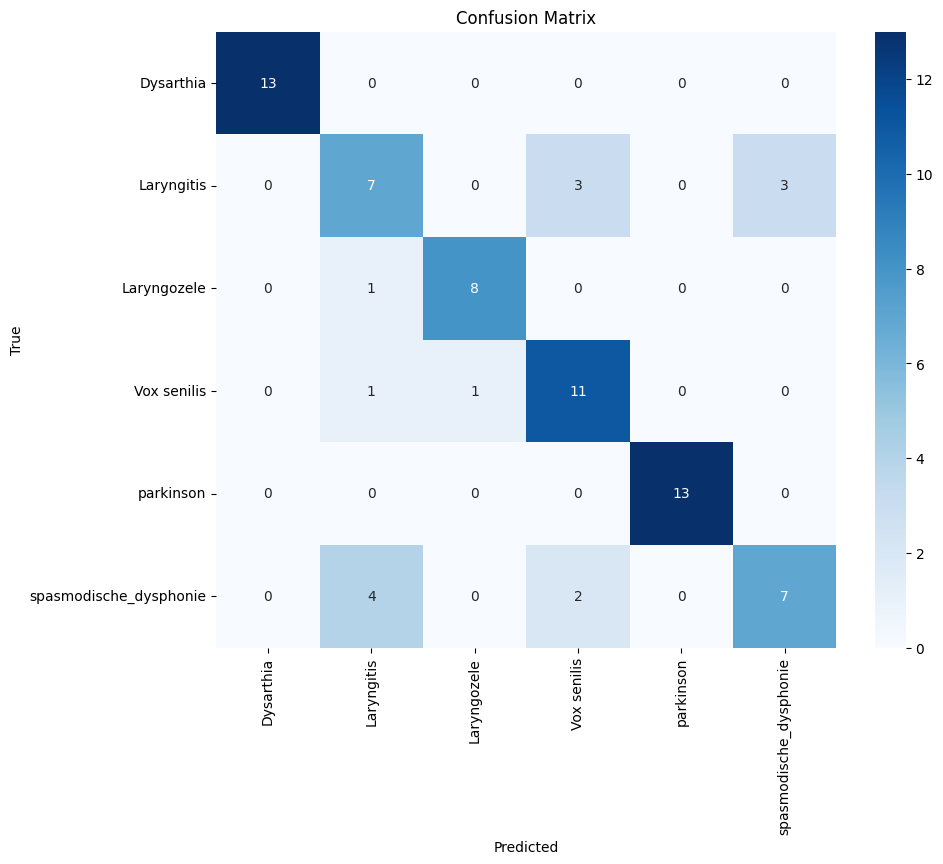

In [4]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import timm
from transformers import AutoModel
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# %% CONFIGURATION
class TestConfig:
    TEST_DIR = "melspectrograms_dataset/test"  # Path to your test folder
    MODEL_PATH = "checkpoints_final/best_model.pth"
    
    IMG_SIZE = 224
    COATNET_MODEL = "coatnet_0_rw_224"
    DINO_MODEL = "facebook/dinov2-small"
    BATCH_SIZE = 32
    NUM_CLASSES = 6
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# %% MODEL DEFINITIONS (Must match training exactly)
class CoAtNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(TestConfig.COATNET_MODEL, pretrained=False, features_only=True)
    def forward(self, x):
        feat = self.model(x)[-1]
        return feat.flatten(2).transpose(1, 2)

class DinoV2Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = AutoModel.from_pretrained(TestConfig.DINO_MODEL)
        self.proj = nn.Linear(768, 384)
        self.pos_embed = self.model.embeddings.position_embeddings
        self.blocks = self.model.encoder.layer
        self.norm = self.model.layernorm
        self.cls_token = self.model.embeddings.cls_token

    def interpolate_pos(self, x):
        patch_pos = self.pos_embed[:, 1:]
        dim = x.shape[-1]
        w_h = int(np.sqrt(x.shape[1] - 1))
        sz = int(np.sqrt(patch_pos.shape[1]))
        patch_pos = patch_pos.reshape(1, sz, sz, dim).permute(0, 3, 1, 2)
        patch_pos = F.interpolate(patch_pos, size=(w_h, w_h), mode='bicubic', align_corners=False)
        return torch.cat((self.pos_embed[:, :1], patch_pos.flatten(2).transpose(1, 2)), dim=1)

    def forward(self, tokens):
        B, N, _ = tokens.shape
        x = self.proj(tokens)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = x + self.interpolate_pos(x)
        for blk in self.blocks: x = blk(x)[0]
        return self.norm(x)[:, 1:, :]

class CrossAttentionHead(nn.Module):
    def __init__(self, dim=384, num_heads=8):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, dim))
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.classifier = nn.Linear(dim, TestConfig.NUM_CLASSES)
        
    def forward(self, x):
        B, N, C = x.shape
        q = self.query.expand(B, -1, -1)
        out, _ = self.attn(q, x, x)
        return self.classifier(out.squeeze(1))

class HybridAudioNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.coatnet = CoAtNetBackbone()
        self.dino = DinoV2Encoder()
        self.head = CrossAttentionHead()

    def forward_features(self, x):
        return self.dino(self.coatnet(x))

# %% DATASET
class TestDataset(Dataset):
    def __init__(self, root, transform):
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_path = os.path.join(root, cls)
            for file in os.listdir(cls_path):
                if file.lower().endswith((".png", ".jpg")):
                    self.samples.append((os.path.join(cls_path, file), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

# %% EVALUATION FUNCTION
def evaluate():
    # 1. Setup
    transform = transforms.Compose([
        transforms.Resize((TestConfig.IMG_SIZE, TestConfig.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
    
    dataset = TestDataset(TestConfig.TEST_DIR, transform)
    loader = DataLoader(dataset, batch_size=TestConfig.BATCH_SIZE, shuffle=False, num_workers=0)
    
    print(f"Loading model from {TestConfig.MODEL_PATH}...")
    model = HybridAudioNet().to(TestConfig.DEVICE)
    model.load_state_dict(torch.load(TestConfig.MODEL_PATH))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    # 2. Inference Loop
    print("Running Inference...")
    with torch.no_grad():
        for x, y in tqdm(loader):
            x = x.to(TestConfig.DEVICE)
            
            # Forward pass (Full tokens, no pruning for best accuracy)
            tokens = model.forward_features(x)
            logits = model.head(tokens)
            
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    # 3. Metrics
    class_names = dataset.classes
    
    # Classification Report
    print("\n" + "="*30)
    print("CLASSIFICATION REPORT")
    print("="*30)
    cr = classification_report(all_labels, all_preds, target_names=class_names)
    print(cr)
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

if __name__ == "__main__":
    evaluate()

🔍 Analyzing: melspectrograms_dataset\test\Vox senilis\846-phrase.png
⏳ Loading Model Weights...


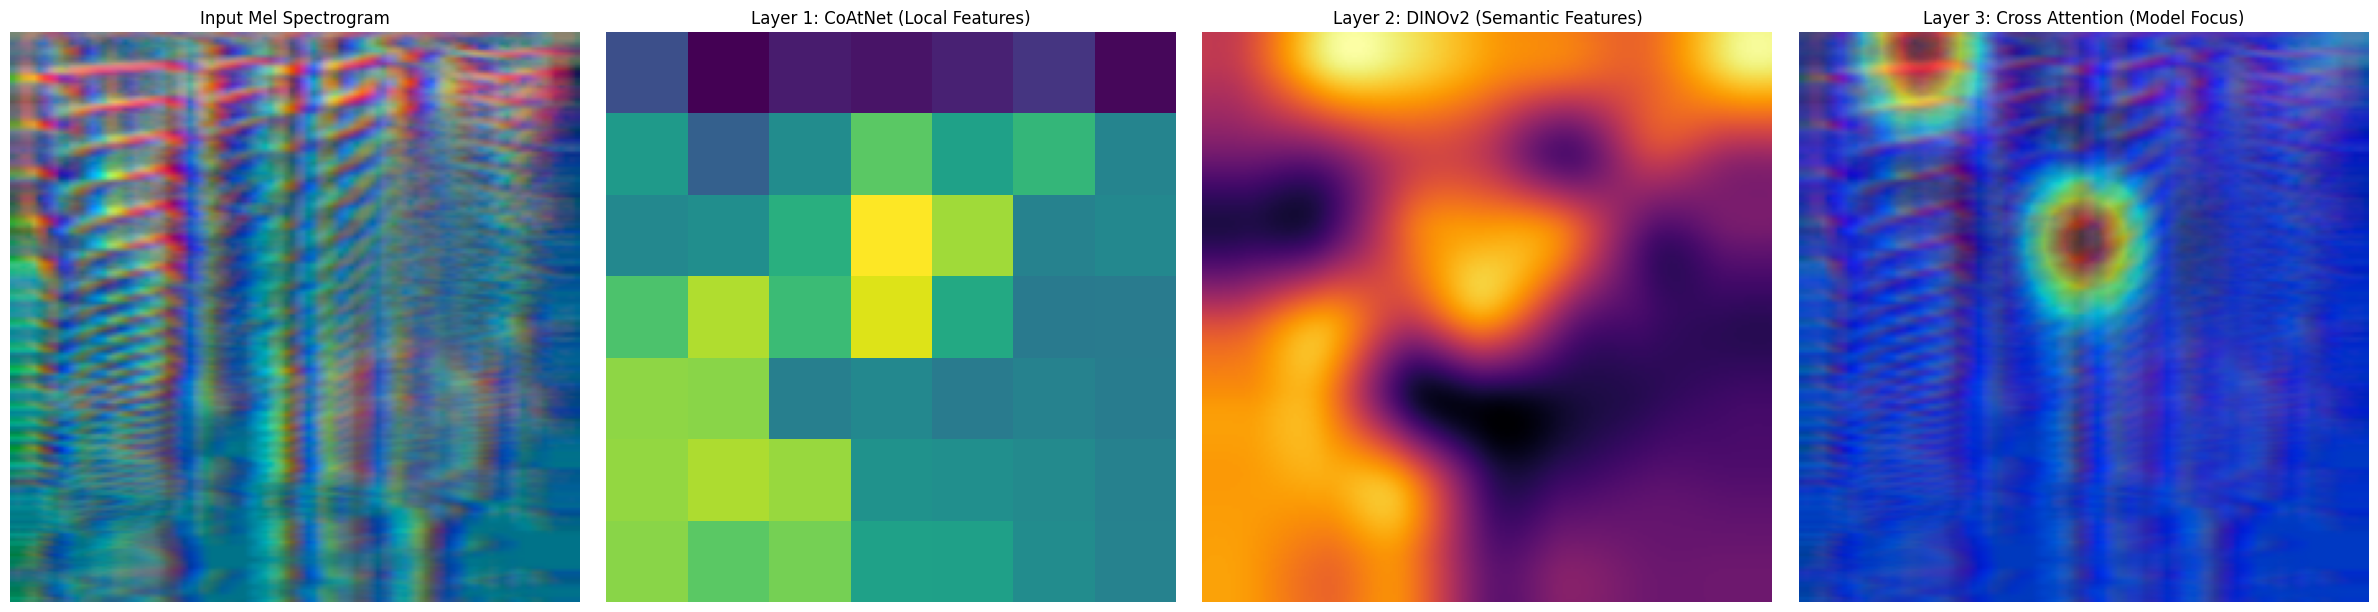

✅ Visualization Generated!


In [11]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import timm
from transformers import AutoModel
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# %% CONFIGURATION
class VizConfig:
    # 1. PATHS
    MODEL_PATH = "checkpoints_final/best_model.pth" 
    
    # ✅ YOUR CORRECT IMAGE PATH IS HERE
    TEST_IMG = r"melspectrograms_dataset\test\Vox senilis\846-phrase.png"
    
    # 2. SETTINGS
    IMG_SIZE = 224
    COATNET_MODEL = "coatnet_0_rw_224"
    DINO_MODEL = "facebook/dinov2-small"
    NUM_CLASSES = 6
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# %% MODEL DEFINITION (Copy of your trained architecture)
class CoAtNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(VizConfig.COATNET_MODEL, pretrained=False, features_only=True)
    def forward(self, x):
        feat = self.model(x)[-1] 
        return feat 

class DinoV2Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = AutoModel.from_pretrained(VizConfig.DINO_MODEL)
        self.proj = nn.Linear(768, 384)
        self.pos_embed = self.model.embeddings.position_embeddings
        self.blocks = self.model.encoder.layer
        self.norm = self.model.layernorm
        self.cls_token = self.model.embeddings.cls_token

    def interpolate_pos(self, x):
        patch_pos = self.pos_embed[:, 1:]
        dim = x.shape[-1]
        w_h = int(np.sqrt(x.shape[1] - 1))
        sz = int(np.sqrt(patch_pos.shape[1]))
        patch_pos = patch_pos.reshape(1, sz, sz, dim).permute(0, 3, 1, 2)
        patch_pos = F.interpolate(patch_pos, size=(w_h, w_h), mode='bicubic', align_corners=False)
        return torch.cat((self.pos_embed[:, :1], patch_pos.flatten(2).transpose(1, 2)), dim=1)

    def forward(self, tokens):
        B, C, H, W = tokens.shape
        x_flat = tokens.flatten(2).transpose(1, 2)
        x = self.proj(x_flat)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = x + self.interpolate_pos(x)
        for blk in self.blocks: x = blk(x)[0]
        return self.norm(x)[:, 1:, :]

class CrossAttentionHead(nn.Module):
    def __init__(self, dim=384, num_heads=8):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, dim))
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.classifier = nn.Linear(dim, VizConfig.NUM_CLASSES)
        
    def forward(self, x, return_weights=True):
        B, N, C = x.shape
        q = self.query.expand(B, -1, -1)
        out, weights = self.attn(q, x, x)
        return out.squeeze(1), weights.squeeze(1)

class HybridAudioNetViz(nn.Module):
    def __init__(self):
        super().__init__()
        self.coatnet = CoAtNetBackbone()
        self.dino = DinoV2Encoder()
        self.head = CrossAttentionHead()

    def forward_viz(self, x):
        features = {}
        # 1. CoAtNet
        coat_feat = self.coatnet(x)
        features['coatnet'] = coat_feat
        # 2. DINO
        dino_out = self.dino(coat_feat)
        features['dino'] = dino_out
        # 3. Attention
        _, attn_weights = self.head(dino_out, return_weights=True)
        features['attention'] = attn_weights
        return features

# %% VISUALIZATION LOGIC
def visualize():
    # 1. Load Image
    if not os.path.exists(VizConfig.TEST_IMG):
        print(f"❌ Error: Still cannot find file at {VizConfig.TEST_IMG}")
        return

    print(f"🔍 Analyzing: {VizConfig.TEST_IMG}")
    raw_img = Image.open(VizConfig.TEST_IMG).convert("RGB")
    
    transform = transforms.Compose([
        transforms.Resize((VizConfig.IMG_SIZE, VizConfig.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
    img_tensor = transform(raw_img).unsqueeze(0).to(VizConfig.DEVICE)
    
    # 2. Load Model
    print("⏳ Loading Model Weights...")
    model = HybridAudioNetViz().to(VizConfig.DEVICE)
    checkpoint = torch.load(VizConfig.MODEL_PATH, map_location=VizConfig.DEVICE)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    
    # 3. Get Features
    with torch.no_grad():
        feats = model.forward_viz(img_tensor)
    
    # 4. Plot
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # Resize raw image for display matching the tensors
    disp_img = raw_img.resize((VizConfig.IMG_SIZE, VizConfig.IMG_SIZE))
    
    # A. Original
    axes[0].imshow(disp_img)
    axes[0].set_title("Input Mel Spectrogram")
    axes[0].axis("off")
    
    # B. CoAtNet (Averaged Channels)
    coat_act = feats['coatnet'][0].mean(dim=0).cpu().numpy()
    sns.heatmap(coat_act, ax=axes[1], cmap="viridis", cbar=False, square=True)
    axes[1].set_title("Layer 1: CoAtNet (Local Features)")
    axes[1].axis("off")
    
    # C. DINO (Reshaped 49 -> 7x7)
    dino_act = feats['dino'][0].reshape(7, 7, -1).mean(dim=-1).cpu().numpy()
    # Interpolate for smoother visualization
    dino_smooth = F.interpolate(torch.tensor(dino_act).unsqueeze(0).unsqueeze(0), 
                                size=(224, 224), mode='bicubic').squeeze().numpy()
    axes[2].imshow(dino_smooth, cmap="inferno")
    axes[2].set_title("Layer 2: DINOv2 (Semantic Features)")
    axes[2].axis("off")
    
    # D. Attention Overlay
    attn_map = feats['attention'][0].reshape(7, 7).cpu().numpy()
    attn_smooth = F.interpolate(torch.tensor(attn_map).unsqueeze(0).unsqueeze(0), 
                                size=(224, 224), mode='bicubic').squeeze().numpy()
    
    axes[3].imshow(disp_img, alpha=1.0) # Show original
    # Overlay heatmap with transparency
    axes[3].imshow(attn_smooth, cmap="jet", alpha=0.5) 
    axes[3].set_title("Layer 3: Cross Attention (Model Focus)")
    axes[3].axis("off")
    
    plt.tight_layout()
    plt.show()
    print("✅ Visualization Generated!")

if __name__ == "__main__":
    visualize()